# Set-up

In [ ]:
import os

# @markdown **Crecerelle:** Install the library from GitHub
!pip install git+https://github.com/Hollfelder-Lab/crecerelle.git

  Cloning https://github.com/Hollfelder-Lab/crecerelle.git to /tmp/pip-req-build-dcswrmdi
  Running command git clone --filter=blob:none --quiet https://github.com/Hollfelder-Lab/crecerelle.git /tmp/pip-req-build-dcswrmdi
  Resolved https://github.com/Hollfelder-Lab/crecerelle.git to commit 33aa181c44a4de0dd8a2baba283e24a61f4e00dd
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 225.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of scanpy to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of anndata to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of scanpy[skmisc] to determine which ver

In [ ]:
# @markdown **Directory structure:** Set-up the directory structure to store the results of Crecerelle. We recommend connecting to your Google Drive. Otherwise, the directories will be created only temporarily in Colab. If you have already set-up the directory structure from a previous analysis, the existing directories will not be overwritten but only the new ones added.

connect_google_drive = True # @param {type:"boolean"}

if connect_google_drive:
    from google.colab import drive
    drive.mount('/content/drive')

    root_directory = "/content/drive/My Drive"
else:
    root_directory = "/content"

Mounted at /content/drive


The following directory structure is then created:
```text
root_directory/
└── crecerelle_results/
    ├── data/
    │   └── <dataset_name>/  *(optional)*
    ├── figures/
    │   └── <dataset_name>/  *(optional)*
    └── models/
        ├── TRVI/
        ├── tuVI/
        └── scVI/

In [ ]:
from crecerelle.utils import setup_crecerelle

# @markdown **Dataset name:** Define the dataset name
dataset_name = "tabulaMuris" # @param

# Set-up the directory structure
setup_crecerelle(root_directory, dataset_name=dataset_name)

# @markdown The working directory is then set to "./crecerelle_results"
if os.path.basename(os.path.normpath(os.getcwd())) != "crecerelle_results":
    os.chdir("drive/My Drive/crecerelle_results")

# Print the working directory
print(f"The working directory is set to: {os.getcwd()}")

Skipped (already exists): /content/drive/My Drive/crecerelle_results
Skipped (already exists): /content/drive/My Drive/crecerelle_results/models
Skipped (already exists): /content/drive/My Drive/crecerelle_results/data
Skipped (already exists): /content/drive/My Drive/crecerelle_results/figures
Skipped (already exists): /content/drive/My Drive/crecerelle_results/models/scVI
Skipped (already exists): /content/drive/My Drive/crecerelle_results/models/tuVI
Skipped (already exists): /content/drive/My Drive/crecerelle_results/models/TRVI
Skipped (already exists): /content/drive/My Drive/crecerelle_results/data/tabulaMuris
Skipped (already exists): /content/drive/My Drive/crecerelle_results/figures/tabulaMuris
The working directory is set to: /content/drive/My Drive/crecerelle_results


In [ ]:
# @markdown **Imports:** modules from PyTorch, Numpy, Scanpy amongst others are imported together with the crecerelle modules necessary for tuVI
# General import
import numpy as np
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
from umap import UMAP
import scib
import pdb
import pandas as pd

# Imports from crecerelle
from crecerelle.cell import TABULA_MURIS_CELL_TYPES, MOUSE_CORTEX_BICCN_CELL_TYPES, TABULA_MURIS_TISSUE_ORGAN_SYSTEM_DICT, TABULA_MURIS_CELL_TYPE_ABBREVIATION_DICT
from crecerelle.utils import GeneExpressionDataset, TranscriptUsageDataset, intron_names_2_integers

# Settings for plotting
plt.rcParams.update({
    'font.size': 16,              # General font size
    'axes.labelsize': 16,         # Font size for x and y labels
    'axes.titlesize': 16,         # Font size for subplot titles
    'xtick.labelsize': 16,        # Font size for x-axis tick labels
    'ytick.labelsize': 16,        # Font size for y-axis tick labels
    'legend.fontsize': 16,        # Font size for legend labels
    #'font.family': 'sans-serif',
    #'font.sans-serif': 'Roboto',
    # 'figure.titlesize': 10,    # Font size for the overall figure title (if you use it)
})

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# @markdown **Specify settings:** These are the general settings for keys to be defined. They are stored in a dictionary called settings. The dataset_name key is already saved in it. The current settings contain the default version for the Tabula Muris dataset.

# @markdown Key of Anndata object specifiying the cell type
settings_cell_type_key = "cell_ontology_class" # @param

# @markdown  Cell types of dataset given
settings_cell_types = TABULA_MURIS_CELL_TYPES # @param

# @markdown Abbreviations of cell types
settings_cell_type_abbreviations = TABULA_MURIS_CELL_TYPE_ABBREVIATION_DICT # @param

# @markdown Organisational entity of cell groups (e.g. tissue)
settings_cell_type_groups_key = "tissue" # @param

# @markdown Name of gene annotation file
settings_gene_annotation = "Mus_musculus.GRCm38.102.chr.gtf.gz" # @param

# @markdown Number of highly variable genes selected (HVGs)
settings_num_hvg = 3000 # @param

# @markdown Data partition used (recommended: "full") for tasks
settings_data_type = "full" # @param

# @markdown Key of Anndata object specifying the data partition (e.g. "train", "val", "test)
settings_data_partition_key = "data_partition" # @param

# @markdown Filter data to cell types with a minimum count
settings_filter_cell_types = True # @param {type:"boolean"}

# @markdown Minimum count threshold for filtering if filter_cell_types is True
settings_min_count_threshold = 100 # @param {type:"integer"}

settings = {
    "dataset_name": dataset_name, # Name of dataset
    "cell_type_key": settings_cell_type_key, # Key of Anndata object specifiying the cell type
    "cell_types": settings_cell_types, # Cell types of dataset given
    "cell_type_abbreviations": settings_cell_type_abbreviations, # Abbreviations of cell types
    "cell_type_groups_key": settings_cell_type_groups_key, # Organisational entity of cell groups (e.g. tissue)
    "gene_annotation": settings_gene_annotation,
    "num_hvg": settings_num_hvg, # Number of highly variable genes selected (HVGs)
    "data_type": settings_data_type, # Data partition used (recommended: "full") for tasks
    "data_partition_key": settings_data_partition_key,
    "filter_cell_types": settings_filter_cell_types, # Filter data to cell types with a minimum count
    "min_count_threshold": settings_min_count_threshold, # Minimum count threshold for filtering if filter_cell_types is True
}

In [ ]:
# @markdown All data files must be stored here and the resulting new data will also be stored here.
path2data = "./data/" + settings["dataset_name"] + "/"

print(f"The data files will be stored in: {path2data}")

The data files will be stored in: ./data/tabulaMuris/


# Loading of data

Ensure the Anndata objects of the gene expression and transcript usage data are uploaded in "./crecerelle_results/data/dataset_name" *(optional)*. The object containing the gene expression matrix should have the prefix "adata_GE" whereas the one containing the transcript usage matrix should start with "adata_TU". Examples are:




*   adata_GE_{data_type}_preprocessed.h5ad
    *   e.g. adata_GE_full_preprocessed.h5ad
*   adata_TU_{data_type}_preprocessed.h5ad
    *   e.g. adata_TU_full_preprocessed.h5ad
*   adata_GE_{num_hvg}_{data_partition}.h5ad
    *   adata_GE_3000_train.h5ad
    *   adata_GE_3000_val.h5ad
    *   adata_GE_3000_test.h5ad

## Transcript usage for tuVI

In [ ]:
# Load transcript usage data
if settings["data_type"] != "full":
    adata_TU = ad.read_h5ad(path2data + "adata_TU_full_preprocessed.h5ad")
    intron_groups_by_name = adata_TU.var["intron_group"].values
    intron_groups = intron_names_2_integers(intron_groups_by_name)
    unique_intron_groups, _ = np.unique(intron_groups, return_index=True)
    num_intron_groups = len(unique_intron_groups)
    adata_TU.obs[settings["data_partition_key"]] = settings["data_type"]

    if settings["filter_cell_types"]:
        cell_types, cell_counts = np.unique(adata_TU.obs[settings["cell_type_key"]].to_numpy(), return_counts=True)
        filtered_cell_types = cell_types[np.argwhere(cell_counts >= settings["min_count_threshold"])].squeeze()

        # Filter adata_GE_train and adata_GE_val to filtered_cell_types
        adata_TU_filtered = adata_TU[adata_TU.obs[settings["cell_type_key"]].isin(filtered_cell_types)].copy()

        adata_TU = adata_TU_filtered

    print(f"Following Anndata object contains the transcript usage data of the data partition {data_type}: \n {adata_TU}")

else:
    # Load transcript usage training data
    adata_TU_train = ad.read_h5ad(path2data + "adata_TU_" + str(settings["num_hvg"]) + "_train.h5ad")
    intron_groups_by_name = adata_TU_train.var["intron_group"].values
    intron_groups = intron_names_2_integers(intron_groups_by_name)
    unique_intron_groups, _ = np.unique(intron_groups, return_index=True)
    num_intron_groups = len(unique_intron_groups)
    adata_TU_train.obs[settings["data_partition_key"]] = "train"

    # Load transcript usage validation data
    adata_TU_val = ad.read_h5ad(path2data + "adata_TU_" + str(settings["num_hvg"]) + "_val.h5ad")
    adata_TU_val.obs[settings["data_partition_key"]] = "val"

    # Load transcript usage test data
    adata_TU_test = ad.read_h5ad(path2data + "adata_TU_" + str(settings["num_hvg"]) + "_test.h5ad")
    adata_TU_test.obs[settings["data_partition_key"]] = "test"

    if settings["filter_cell_types"]:
        cell_types, cell_counts = np.unique(adata_TU_train.obs[settings["cell_type_key"]].to_numpy(), return_counts=True)
        filtered_cell_types = cell_types[np.argwhere(cell_counts >= settings["min_count_threshold"])].squeeze()

        # Filter adata_GE_train and adata_GE_val to filtered_cell_types
        adata_TU_train_filtered = adata_TU_train[adata_TU_train.obs[settings["cell_type_key"]].isin(filtered_cell_types)].copy()
        adata_TU_val_filtered = adata_TU_val[adata_TU_val.obs[settings["cell_type_key"]].isin(filtered_cell_types)].copy()
        adata_TU_test_filtered = adata_TU_test[adata_TU_test.obs[settings["cell_type_key"]].isin(filtered_cell_types)].copy()

        adata_TU_train = adata_TU_train_filtered
        adata_TU_val = adata_TU_val_filtered
        adata_TU_test = adata_TU_test_filtered

    adata_TU = ad.concat([adata_TU_train, adata_TU_val, adata_TU_test], axis=0, join="outer", merge="same")

# @markdown **Filter cells in taxonomy level:** Per taxonomy level, filter out all cell types with less than min_cells
min_cells_per_tax_level = 50 # @param {type:"integer"}

if min_cells_per_tax_level > 0:
    # 1. Calculate the size of each cell type group within each tissue
    # transform('size') returns a Series with the same index as the original dataframe
    counts = adata_TU.obs.groupby([settings["cell_type_groups_key"], settings["cell_type_key"]])[settings["cell_type_key"]].transform('size')

    # 2. Create a boolean mask for cells to keep
    keep_mask = counts >= min_cells_per_tax_level

    # 3. Slice both AnnData objects in the tuple
    adata_filtered = adata_TU[keep_mask, :].copy()


    adata_filtered.obs[settings["cell_type_key"]] = adata_filtered.obs[settings["cell_type_key"]].cat.remove_unused_categories()

    adata_TU = adata_filtered.copy()

print(f"Following Anndata object contains the transcript usage data of the data partition {settings["data_type"]}: \n {adata_TU}")

# Create dataset and dataloader
cell_intron_counts = torch.from_numpy(adata_TU.layers["counts"].toarray())
#cell_intron_levels = torch.from_numpy(adata_TU_train.layers["psi"])
cell_intron_levels = torch.from_numpy(adata_TU.X.toarray())

transform_intron_counts = None # Previously "log" but incorrect
transform_intron_levels = None
transform_ontology = "one-hot"

# @markdown **Dataset:** Create the dataset of transcript usage for inference with tuVI
transcript_usage_dataset = TranscriptUsageDataset(
    cell_intron_counts=cell_intron_counts,
    cell_intron_levels=cell_intron_levels,
    ontology=adata_TU.obs[settings["cell_type_key"]].to_numpy(),
    tissue=adata_TU.obs[settings["cell_type_groups_key"]].to_numpy(),
    cell_types= cell_types,
    transform_intron_counts=transform_intron_counts,
    transform_intron_levels=transform_intron_levels,
    transform_ontology=transform_ontology
)

print(f"The dataset is set up for inference.")

/tmp/ipykernel_27753/1013656764.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = adata_TU.obs.groupby([settings["cell_type_groups_key"], settings["cell_type_key"]])[settings["cell_type_key"]].transform('size')
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Following Anndata object contains the transcript usage data of the data partition full: 
 AnnData object with n_obs × n_vars = 36256 × 2319
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'cell_type', 'plate_id', 'data_partition'
    var: 'chromosome', 'start', 'end', 'strand', 'annotated', 'gene_id_start', 'gene_id_end', 'n_genes', 'gene_id', 'gene_name', 'intron_group', 'intron_group_size', 'n_genes_per_intron_group'
    layers: 'counts', 'psi'
The dataset is set up for inference.


# Model settings for tuVI

In [ ]:
# @markdown **Path to models:** Ensure all tuVI models trained have been saved in this path
settings_path2models = "./models/tuVI/" # @param
settings["path2models"] = settings_path2models

print(f"The tuVI models trained are chosen from the path {settings["path2models"]}")
print(f"Currently, follwing models are present in {settings["path2models"]}: ")

from pathlib import Path
for model_file in Path(settings["path2models"]).iterdir():
    print(model_file.name)

The tuVI models trained are chosen from the path ./models/tuVI/
Currently, follwing models are present in ./models/tuVI/: 
Archive
tabulaMuris_3000_tuVI_ZANIDM_9_Beta_010_epochs_22_checkpoint.pth
tabulaMuris_3000_tuVI_ZANIDM_7_Beta_010_epochs_21_checkpoint.pth
tabulaMuris_3000_tuVI_ZANIDM_8_Beta_010_epochs_20_checkpoint.pth
tabulaMuris_3000_tuVI_ZANIDM_6_Beta_010_epochs_22_checkpoint.pth
tabulaMuris_3000_tuVI_ZANIDM_5_Beta_010_epochs_22_checkpoint.pth
tabulaMuris_3000_tuVI_ZANIDM_4_Beta_010_epochs_21_checkpoint.pth
tabulaMuris_3000_tuVI_ZANIDM_2_Beta_010_epochs_21_checkpoint.pth
tabulaMuris_3000_tuVI_ZANIDM_3_Beta_010_epochs_20_checkpoint.pth
tabulaMuris_3000_tuVI_ZANIDM_0_Beta_010_epochs_22_checkpoint.pth
tabulaMuris_3000_tuVI_ZANIDM_1_Beta_010_epochs_21_checkpoint.pth
tabulaMuris_3000_tuVI_ZIDM_9_Beta_010_epochs_136_checkpoint.pth
tabulaMuris_3000_tuVI_ZIDM_8_Beta_010_epochs_157_checkpoint.pth
tabulaMuris_3000_tuVI_ZIDM_6_Beta_010_epochs_148_checkpoint.pth
tabulaMuris_3000_tuVI_ZIDM_

In [ ]:
# @markdown **Dimension of latent space:** Define the dimensionality of the cell embeddings
latent_dim = 10 # @param {type:"integer"}

# @markdown **Beta parameter:** Choose the value for the beta parameter
beta = 1.0 # @param {type:"number"}

# @markdown **Architecture of neural networks:** choose the number of hidden layers as well as the number of hidden units per layer for the encoding and decoding neural networks
num_hidden_layers = 2 # @param {type:"integer"}
num_hidden_units = 256 # @param {type:"integer"}

# @markdown **Dropout rate:** If dropout shall be applied, set the dropout rate to 0.0 > p > 1.0. Otherwise, choose 0.0.
dropout_rate = 0.1 # @param {type:"number"}
scaling_factor = True # @param {type:"boolean"}
device = "cuda" # @param ["cuda", "cpu"]

# Convert beta to string
beta_str = f"{beta:.1f}"
beta_str = beta_str.replace(".", "")
while len(beta_str) < 3:
    beta_str = "0" + beta_str

## tuVI with DM observation model

In [ ]:
from crecerelle.models import DMTranscriptUsageVAE

model = DMTranscriptUsageVAE(
    input_dim=transcript_usage_dataset.num_introns,
    num_intron_groups=num_intron_groups,
    intron_groups = intron_groups,
    latent_dim=latent_dim,
    beta=beta,
    num_hidden_layers=num_hidden_layers,
    num_hidden_units=num_hidden_units,
    dropout_rate=dropout_rate,
    device=device,
    scaling_factor=False # by default
)

observation_model = "DM"
count_data_included = True

model

DMTranscriptUsageVAE(
  (encoder): Encoder(
    (encoder): FCLayers(
      (fc_layers): ModuleList(
        (0): Sequential(
          (linear): Linear(in_features=2319, out_features=256, bias=True)
          (batchnorm): BatchNorm1d(256, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (activation): ReLU()
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (1): Sequential(
          (linear): Linear(in_features=256, out_features=256, bias=True)
          (batchnorm): BatchNorm1d(256, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (activation): ReLU()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (mean_encoder): Linear(in_features=256, out_features=10, bias=True)
    (var_encoder): Linear(in_features=256, out_features=10, bias=True)
  )
  (decoder): IntronsDecoder(
    (non_linear_layers): FCLayers(
      (fc_layers): ModuleList(
        (0): Sequential(
          (linear): Linear(i

## tuVI with ZANIDM observation model

In [ ]:
from crecerelle.models import ZANIDMTranscriptUsageVAE

# @markdown **Observation model of tuVI:** Zero-and-N-inflated Dirichlet-Multinomial likelihood
model = ZANIDMTranscriptUsageVAE(
    input_dim=transcript_usage_dataset.num_introns,  # number of introns
    num_intron_groups=num_intron_groups,
    intron_groups=intron_groups,
    latent_dim=latent_dim,
    beta=beta,
    num_hidden_layers=num_hidden_layers,
    num_hidden_units=num_hidden_units,
    dropout_rate=dropout_rate,
    device=device
)

observation_model = "ZANIDM"
count_data_included = True

model

ZANIDMTranscriptUsageVAE(
  (encoder): Encoder(
    (encoder): FCLayers(
      (fc_layers): ModuleList(
        (0): Sequential(
          (linear): Linear(in_features=2319, out_features=256, bias=True)
          (batchnorm): BatchNorm1d(256, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (activation): ReLU()
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (1): Sequential(
          (linear): Linear(in_features=256, out_features=256, bias=True)
          (batchnorm): BatchNorm1d(256, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (activation): ReLU()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (mean_encoder): Linear(in_features=256, out_features=10, bias=True)
    (var_encoder): Linear(in_features=256, out_features=10, bias=True)
  )
  (decoder): ZANIDMTranscriptUsageDecoder(
    (decoding_layers): FCLayers(
      (fc_layers): ModuleList(
        (0): Sequential(
          (l

## tuVI with ZIDM heuristic observation model

In [ ]:
from crecerelle.models import ZIDMTranscriptUsageVAE

model = ZIDMTranscriptUsageVAE(
    input_dim=transcript_usage_dataset.num_introns,  # number of introns
    num_intron_groups=num_intron_groups,
    intron_groups=intron_groups,
    latent_dim=latent_dim,
    beta=beta,
    num_hidden_layers=num_hidden_layers,
    num_hidden_units=num_hidden_units,
    dropout_rate=dropout_rate,
    device=device
)

observation_model = "ZIDM"
count_data_included = True

model

ZIDMTranscriptUsageVAE(
  (encoder): Encoder(
    (encoder): FCLayers(
      (fc_layers): ModuleList(
        (0): Sequential(
          (linear): Linear(in_features=2319, out_features=256, bias=True)
          (batchnorm): BatchNorm1d(256, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (activation): ReLU()
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (1): Sequential(
          (linear): Linear(in_features=256, out_features=256, bias=True)
          (batchnorm): BatchNorm1d(256, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (activation): ReLU()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (mean_encoder): Linear(in_features=256, out_features=10, bias=True)
    (var_encoder): Linear(in_features=256, out_features=10, bias=True)
  )
  (decoder): ZIDMTranscriptUsageDecoder(
    (decoding_layers): FCLayers(
      (fc_layers): ModuleList(
        (0): Sequential(
          (linea

# Comparison of different random seeds for tuVI

To select the model, define the seeds and the corresponding epoch checkpoints of the tuVI models you want to evaluate. Then, choose an evaluation metric to asses the fidelity of the learnt generative model (e.g. negative log-likelihood (nll), root mean squared error (rmse)). We recommend the negative log-likelihood (nll). For the Tabula Muris we had following seeds and epoch checkpoints:

*   tuVI-DM:
    *   seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
    *   epoch checkpoints: [71, 50, 53, 61, 58, 99, 83, 75, 91, 63]

*   tuVI-ZANIDM:
    *   seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
    *   epoch checkpoints: [22, 21, 21,20, 21, 22, 22, 21, 20, 22]

*   tuVI-ZIDM:
    *   seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
    *   epoch checkpoints: [147, 118, 105, 109, 112, 129, 148, 71, 157, 136]


In [ ]:
# @markdown **List of random seeds:** Define the random seeds to be evaluated
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] # @param

# @markdown **Epoch checkpoints:** Choose per seed selected the according epoch checkpoint
epoch_checkpoints = [71, 50, 53, 61, 58, 99, 83, 75, 91, 63] # @param

# @markdown **Evaluation metric:** Choose the evaluation metric
eval_metric = "nll" # @param ["nll", "rmse"]


Across the models and their seeds chosen, the robustness is evaluated by calculating the overall average of the evaluation metric and the overall standard deviation. We recommend to use models beneath both thresholds for the downstream tasks.

In [ ]:
from crecerelle.utils import run_random_seed_evaluation_VAE

adata = adata_TU.copy()
dataset = transcript_usage_dataset
model.eval()

batch_size = 256

# Run random seed evaluation
adata = run_random_seed_evaluation_VAE(
    model=model,
    observation_model=observation_model,
    beta_str=beta_str,
    list_of_random_seeds=seeds,
    list_of_epoch_checkpoints=epoch_checkpoints,
    adata=adata,
    dataset=dataset,
    dataset_name=settings["dataset_name"],
    num_hvg=settings["num_hvg"],
    path2models=settings["path2models"],
    data_modality="Transcript usage",
    device=device,
    count_data_included=count_data_included,
    batch_size=batch_size,
)

print(f"Random seeds have been evaluated for {seeds} and the results saved in the AnnData object: \n")
adata

Random seeds have been evaluated for [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] and the results saved in the AnnData object: 



/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


AnnData object with n_obs × n_vars = 36256 × 2319
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'cell_type', 'plate_id', 'data_partition', 'DM_0_nll', 'DM_1_nll', 'DM_2_nll', 'DM_3_nll', 'DM_4_nll', 'DM_5_nll', 'DM_6_nll', 'DM_7_nll', 'DM_8_nll', 'DM_9_nll'
    var: 'chromosome', 'start', 'end', 'strand', 'annotated', 'gene_id_start', 'gene_id_end', 'n_genes', 'gene_id', 'gene_name', 'intron_group', 'intron_group_size', 'n_genes_per_intron_group'
    obsm: 'DM_0_latent_mean', 'DM_0_X_umap', 'DM_1_latent_mean', 'DM_1_X_umap', 'DM_2_latent_mean', 'DM_2_X_umap', 'DM_3_latent_mean', 'DM_3_X_umap', 'DM_4_latent_mean', 'DM_4_X_umap', 'DM_5_latent_mean', 'DM_5_X_umap', 'DM_6_latent_mean', 'DM_6_X_umap', 'DM_7_latent_mean', 'DM_7_X_umap', 'DM_8_latent_mean', 'DM_8_X_umap', 'DM_9_latent_mean', 'DM_9_X_umap'
    layers: 'counts', 'psi', 'DM_0_r

To assess the robustness the random seeds of tuVI, the performance of the generative model is assessed by the evaluation metric chosen.

In [ ]:
# Evaluate reconstructions
from crecerelle.utils import evaluate_random_seeds_reconstructions

eval_metric_df = evaluate_random_seeds_reconstructions(
        seeds,
        adata,
        observation_model,
        "test",
        eval_metric
)

# Calculate mean and std
eval_metric_df_mean = eval_metric_df.mean()
eval_metric_df_std = eval_metric_df.std()

# Rename the series so they become the column names in the new DataFrame
eval_metric_df_mean.name = "Mean of " + eval_metric
eval_metric_df_std.name = "Std of " + eval_metric

# Concatenate them along columns (axis=1)
eval_metric_mean_std_df = pd.concat([eval_metric_df_mean, eval_metric_df_std], axis=1)

# @markdown **Save evaluation:**
save_eval_metric = False #@param {type:"boolean"}
if save_eval_metric:
    # Save the single merged DataFrame instead of two separate files
    eval_metric_mean_std_df.to_csv(path2data + "model_selection_tuVI_" + observation_model + "_eval_metric_summary.csv")
    print(f"The evaluation metric summary is saved in {path2data}")



/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Display the evaluation metric data frame
eval_metric_mean_std_df

,Mean of nll,Std of nll
DM_0_nll,65.379478,54.629200
DM_1_nll,65.531448,54.586571
DM_2_nll,65.836029,54.610950
DM_3_nll,65.434975,54.497551
DM_4_nll,65.523392,54.569469
DM_5_nll,65.094994,54.504673
DM_6_nll,65.178360,54.592705
DM_7_nll,65.438904,54.423042
DM_8_nll,65.263512,54.498455
DM_9_nll,65.288139,54.575706


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


The best seed is 5 and the worst seed is 2


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


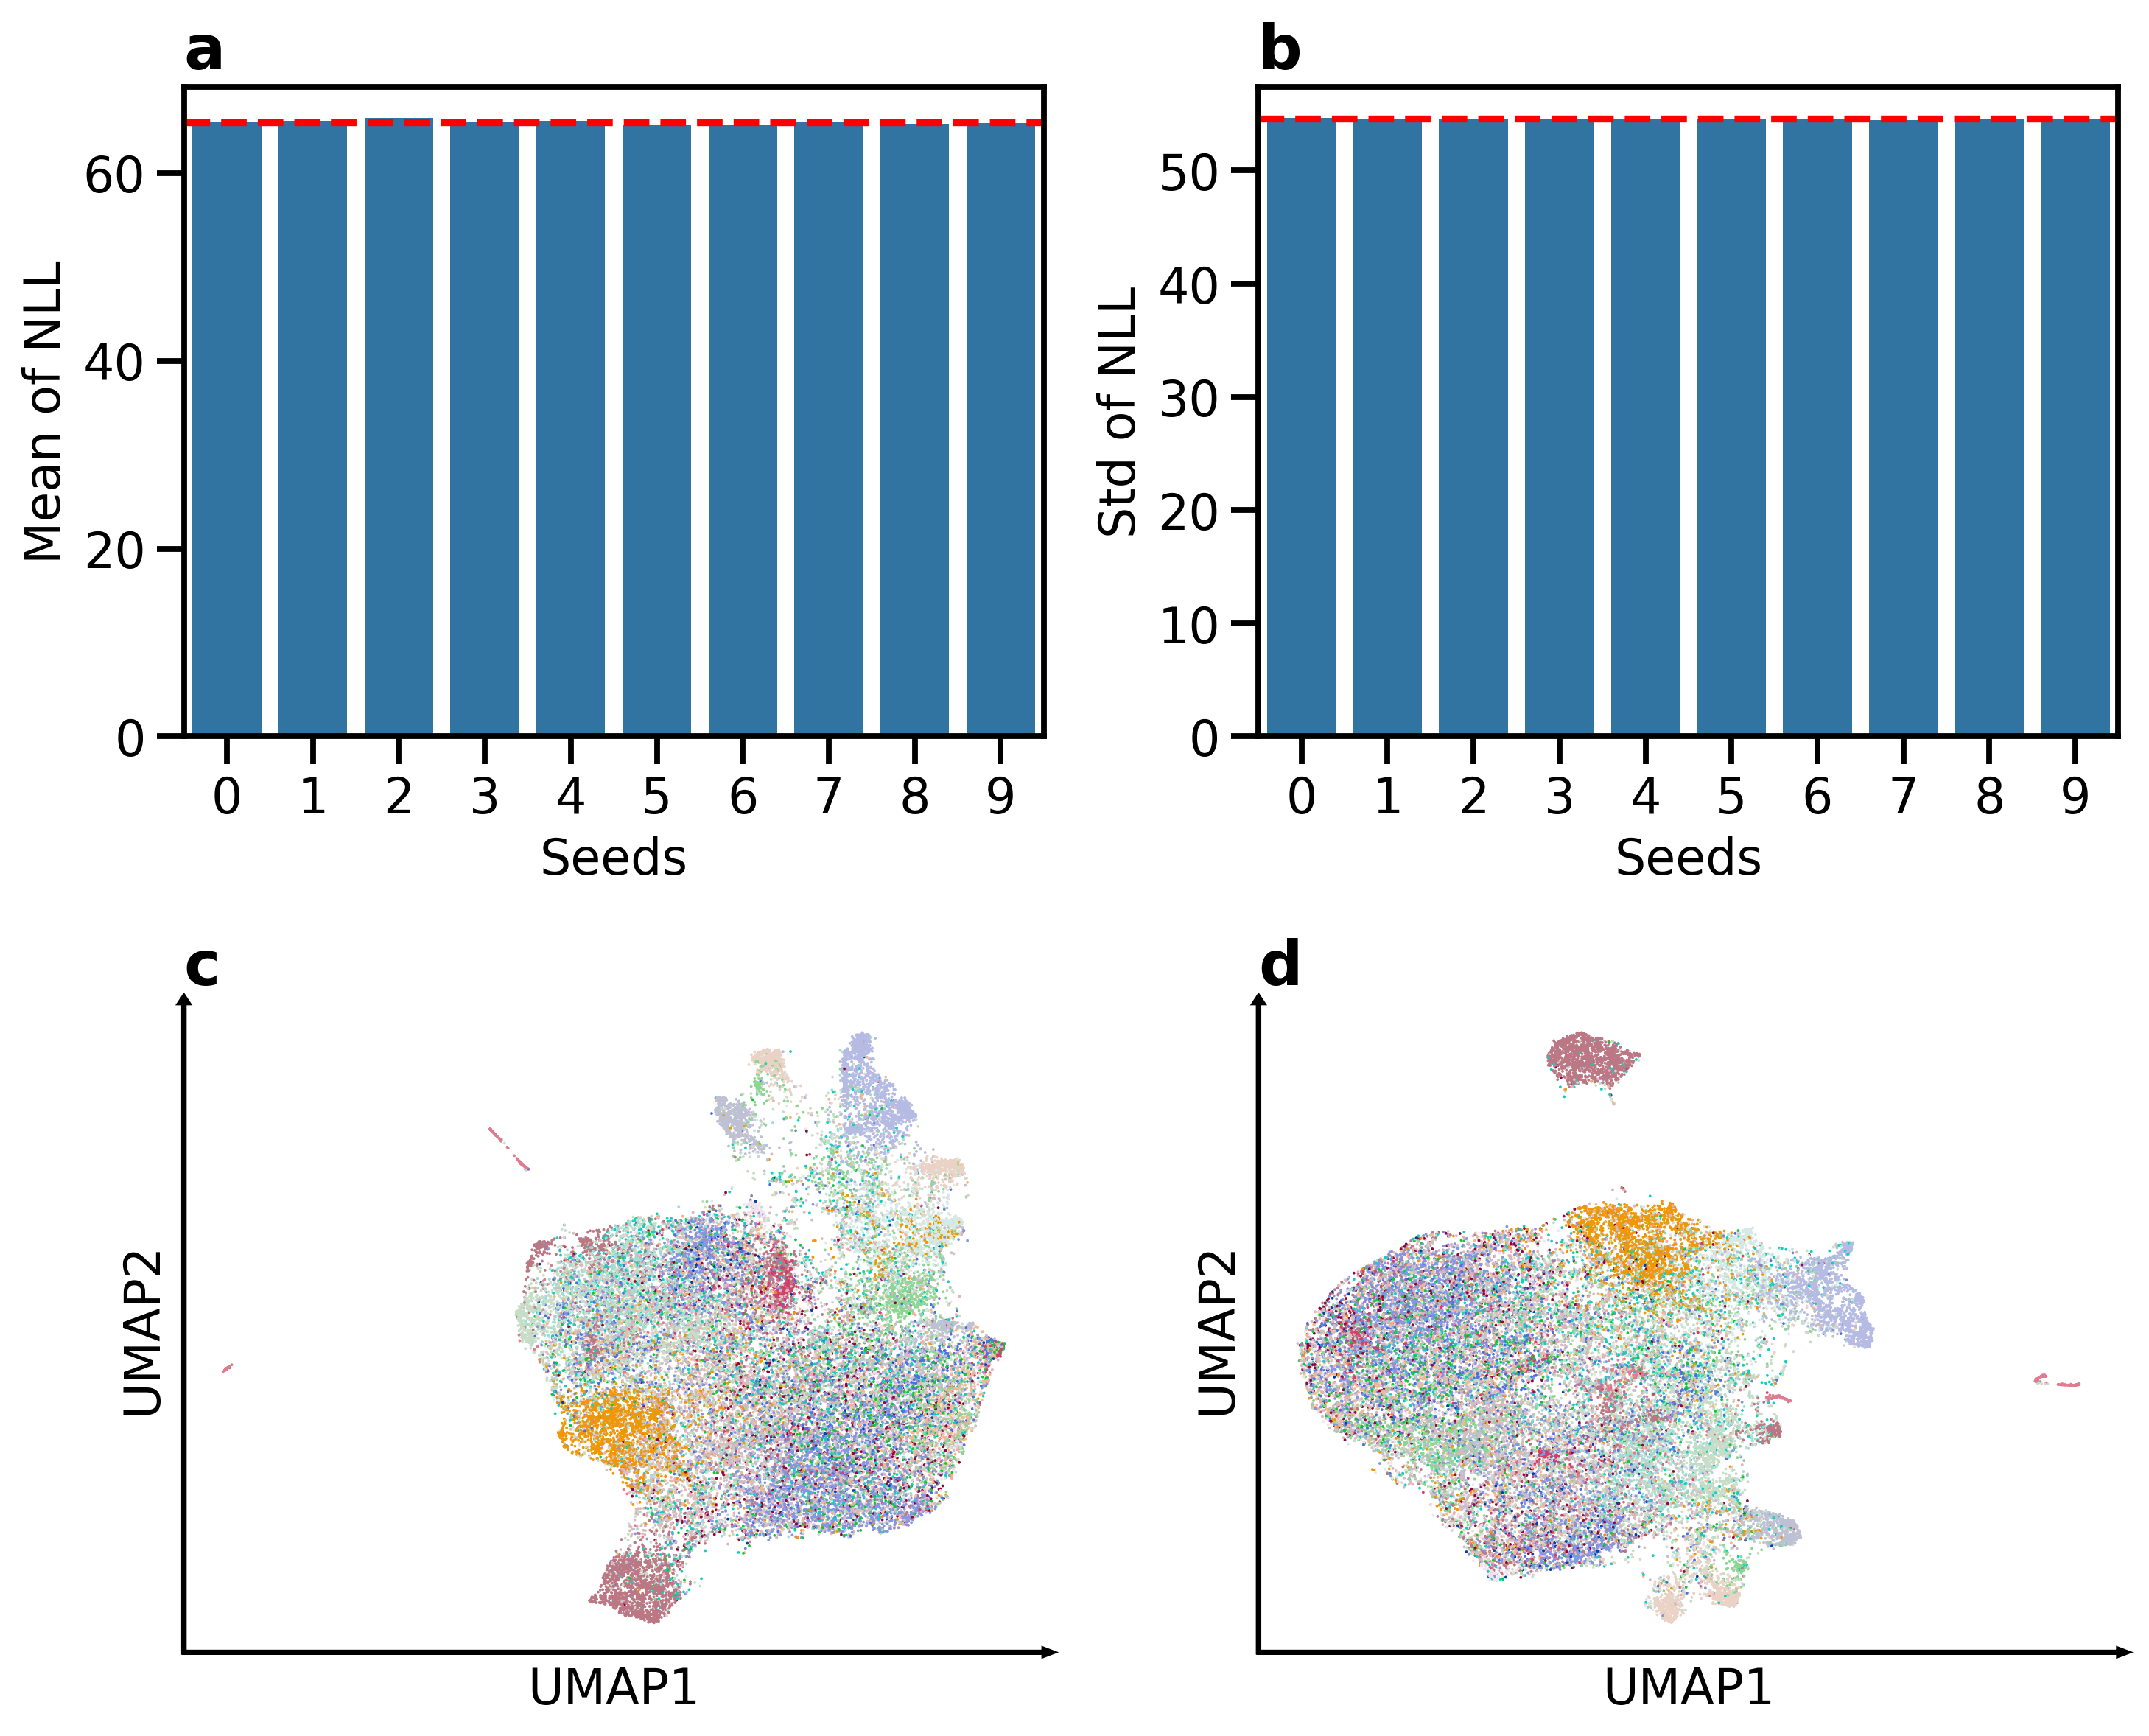

In [ ]:
# Plot random seed evaluation
from crecerelle.plotting_utils import plot_random_seed_comparison_VAE

# @markdown **Plotting:** Save figure
save_fig = False #@param {type:"boolean"}

plot_random_seed_comparison_VAE(
    adata=adata,
    observation_model=observation_model,
    list_of_random_seeds=seeds,
    eval_metric_df=eval_metric_df,
    eval_metric=eval_metric,
    display_box_plot=False,
    save_fig=save_fig,
    dataset_name=settings["dataset_name"]
)

For *Tabula Muris* following models have been selected for downstream tasks:


*   tuVI-DM: 5
*   tuVI-ZANIDM:6
*   tuVI_ZIDM: 1

